# Week 3 Group 4: Concept Network Analysis with AI Component

This notebook analyzes concept networks with a focus on angular relationships relative to AI components.

## Table of Contents
1. [Data Loading & Preprocessing](#section1)
2. [Network Analysis](#section2)
3. [Angle Calculation (Circular Statistics)](#section3)
4. [AI-Relative Angle Analysis](#section4)
5. [Data Integration & Normalization](#section5)
6. [Visualization](#section6)

---

<a id='section1'></a>
## 1. Data Loading & Preprocessing

Loading ego network data and filtering to sessions containing 'AI' as a concept.

In [2]:
# Part 1. Merging Ego and Alter Networks
 
import networkx as nx 
import pandas as pd 
from pathlib import Path

# Set the path to our files. For me it is under this folder in 
# "Network Canvas Export Tables"
file_path = Path.cwd() / "/Users/celikhanbaylan/Desktop/OII/FSDS/Network Canvas Export Tables"
file_list = file_path.glob(file_path / "*attributeList_concept.csv")

# The trickiest part is managing the linking key which comes from the file name
concept_files = [] 
for i in file_path.glob("*attributeList_concept.csv"):
    df_temp = pd.read_csv(i)
    session_id = i.name.split("_")[1]
    df_temp["session_id"] = session_id
    concept_files.append(df_temp)

# Concatenate all the alter files, then reset the index
df_alters = pd.concat(concept_files)
df_alters.reset_index()

# Now we explore the ego_files: 
# We can merge these directly where df_alter["session_id"] == ["networkCanvasSessionID"]
ego_files = []
for i in file_path.glob("*_ego.csv"):
    ego_files.append( pd.read_csv(i))

df_ego = pd.concat(ego_files)

df_alters = df_alters.merge(df_ego, left_on="session_id", right_on="networkCanvasSessionID")

# Filter: Keep only sessions that contain 'AI' as a concept
sessions_with_ai = df_alters[df_alters['name'] == 'AI']['session_id'].unique()
df_alters = df_alters[df_alters['session_id'].isin(sessions_with_ai)]
print(f"Filtered to {len(sessions_with_ai)} sessions with 'AI' component")

# For a brief report, we can check the value_counts of the name variable
df_alters["name"].value_counts()

Filtered to 15 sessions with 'AI' component


name
AI                 15
ethics             10
technology         10
analysis            9
knowledge           9
empirical data      9
theory              7
context             7
community           6
perspective         6
truth               6
optimisation        5
social networks     5
change              5
culture             5
structure           4
progress            4
identity            4
development         4
policy              4
inequality          4
social norms        3
power               3
macro-micro         3
design              2
justice             2
user experience     2
privacy             2
art                 1
personal            1
gender              1
music               1
freedom             1
history             1
collective          1
individual          1
race-ethnicity      1
Name: count, dtype: int64

In [3]:
# Part 2. Merging in Giant Component data
# This is considerably more challenging overall. 

# To attempt this, I first build a dictionary {"sessionID":file_path}
# I do this so later we know which path to merge with which session data.
# Only process sessions that contain AI
edge_list = []
for i in file_path.glob("*ego.csv"):
    x = i.name.split("_")[:-1]
    x.append("edgeList_relate.csv")
    edge_path = Path(file_path / "_".join(x))
    key = i.name.split("_")[1]
    
    # Skip sessions without AI component
    if key not in sessions_with_ai:
        continue
    
    if edge_path.exists():
        edge_list.append(
            {"key":key,
             "path":edge_path
             })
    else:
        raise Exception("Warning: The edge path file does not exist.") 

# Now we can iterate through the paths. 
# For each path we create a network. I did this by:
# reading the CSV to a DataFrame
# taking the source and target columns as lists
# zipping the list: this way instead of [1,2,3,4], [a,b,c,d] we have [(1,a), (2,b), (3,c), (4,d)]
# a zip object is a 'generator' but we need it as list, so its list(zip(l1,l2))

edgelist_dfs = []
for edge_file in edge_list:
    edge_df = pd.read_csv(edge_file["path"])
    edges = zip(edge_df["networkCanvasSourceUUID"].to_list(),edge_df["networkCanvasTargetUUID"].to_list())
    edges = list(edges)
    G = nx.Graph(edges)
        
    # Once we have the zipped list, these are the edges. We can then check the giant component.
    ccs = sorted(list(nx.connected_components(G)), key=len, reverse=True)

    # Sort components to check if same length
    giant_component = ccs[0]
    if len(ccs) > 1:
        for i in ccs[1:]:
            if len(i) == len(ccs[0]):
                giant_component.extend(i)

    # Now we create a temporary dataframe with two columns: 
    # networkCanvasUUID (which is the ID of the concept)
    # networkCanvasSessionID (which is the joining key)
    df_temp = pd.DataFrame(giant_component, columns=["networkCanvasUUID"])
    df_temp["networkCanvasSessionID"] = edge_file["key"]
    # And we add "in_gcc" = 1, later we populate all the rest as 0
    df_temp["in_gcc"] = 1
    edgelist_dfs.append(df_temp)

# We concatenate all the components into a single DataFrame
# And then we use (and this is tricky as it was not mentioned in the lecture: )
df_edgelist_gcc = pd.concat(edgelist_dfs) 
df_alters = df_alters.merge(df_edgelist_gcc, on=["networkCanvasSessionID","networkCanvasUUID"], how="left")

# Where we didn't get a value from the merge, that node was not in the giant component for that ego
df_alters.fillna({"in_gcc":0}, inplace = True)

df_alters["in_gcc"].value_counts()

in_gcc
1.0    125
0.0     39
Name: count, dtype: int64

---

<a id='section2'></a>
## 2. Network Analysis

Aggregating concept data and analyzing network properties.

# Q2. Aggregating networks

Now with your `df_alter` DataFrame table, aggregate over the concepts to produce `df_concepts`, counting:
  - the number of times they appear 
  - the number of times they appear in the giant component

Q2.1: Descriptive questions: 
- How many concepts appear in total? 
- Which concept appears the most? Please produce a table ranking the concepts from most to least common. 

# Q2 Answer below here 

Please use markdown or python cells as necessary. 

In [4]:
# We filter first to the columns of interest: name and 'in_gcc'
# Then we groupby and get a count of these as well as a sum.
# Count will get us how many times the concept appeared; 
# Sum will get us how many times it appeared in the giant component.
df_concepts = df_alters[["name","in_gcc"]].groupby("name").agg(["count","sum"])
df_concepts.columns = ["concept_count", "concept_sum"]
df_concepts.sort_values("concept_count",ascending=False,inplace=True)
df_concepts

,concept_count,concept_sum
name,,
AI,15,12.0
technology,10,9.0
ethics,10,8.0
knowledge,9,7.0
analysis,9,8.0
empirical data,9,8.0
theory,7,6.0
context,7,6.0
perspective,6,5.0


✓ Calculated distance for 37 concepts

📊 Top 10 concepts closest to center:
                mentions  distance
name                              
design                 2  0.081255
collective             1  0.083550
freedom                1  0.085239
history                1  0.103096
individual             1  0.107629
personal               1  0.109637
community              6  0.116061
empirical data         9  0.119160
truth                  6  0.129760
analysis               9  0.131422


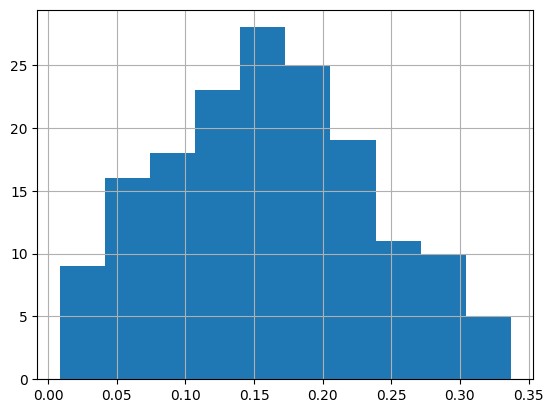

In [5]:
# ============================================================
# Q3.1: EUCLIDEAN DISTANCE FROM CENTER
# ============================================================

import numpy as np

# Calculate distance from center (0.5, 0.5) for each concept
# distance = np.linalg.norm([x - 0.5, y - 0.5])
df_alters['distance'] = df_alters.apply(
    lambda row: np.linalg.norm([row['user_layout_x'] - 0.5, row['user_layout_y'] - 0.5]), 
    axis=1
)

# Visualize distance distribution
df_alters["distance"].hist()

# Aggregate by concept: count mentions and mean distance
df_concepts_2 = df_alters[["name","distance"]].groupby("name").agg(["count","mean"])
df_concepts_2.columns = ["mentions","distance"]

# Sort by distance (closest to center first)
df_concepts_2.sort_values("distance", inplace=True)

print(f"✓ Calculated distance for {len(df_concepts_2)} concepts")
print(f"\n📊 Top 10 concepts closest to center:")
print(df_concepts_2.head(10))


In [6]:
# ============================================================
# Q3.2: NEAREST ANGLE NODE
# ============================================================

import numpy as np
import pandas as pd

# Function to calculate smallest angular distance
def angular_distance(angle1, angle2):
    """Calculate smallest angular distance between two angles (in radians)"""
    diff = np.abs(angle1 - angle2)
    return np.minimum(diff, 2*np.pi - diff)

# Find nearest node by angle within each ego network
def find_nearest_node_in_egonet(group):
    """Helper function to find nearest angle within a group"""
    angles = group['angle_rad'].values
    indices = group.index.values
    n = len(angles)
    
    # Edge case: single node
    if n <= 1:
        return pd.Series([None] * n, index=indices)
    
    # Create angular distance matrix
    angle_diff = np.abs(angles[:, None] - angles[None, :])
    angular_dist = np.minimum(angle_diff, 2*np.pi - angle_diff)
    
    # Set diagonal to infinity (avoid self-matching)
    np.fill_diagonal(angular_dist, np.inf)
    
    # Get nearest index for each row
    nearest_positions = np.argmin(angular_dist, axis=1)
    nearest_indices = indices[nearest_positions]
    
    return pd.Series(nearest_indices, index=indices)

def find_nearest_node(df, category):
    """Vectorized version using groupby"""
    nearest_node = (df
                    .groupby(category, group_keys=False)
                    .apply(find_nearest_node_in_egonet, include_groups=False))
    return nearest_node.map(df_alters['name'])

# Calculate angle in radians if not already present
if 'angle_rad' not in df_alters.columns:
    df_alters['angle_rad'] = np.arctan2(
        df_alters['user_layout_x'] - 0.5, 
        df_alters['user_layout_y'] - 0.5
    )

# Find nearest angle node for each concept
df_alters['nearest_angle_node'] = find_nearest_node(df_alters, "session_id")

# Aggregate by concept: most common nearest neighbor
df_concepts_3 = df_alters[["name","nearest_angle_node"]].groupby("name").agg(
    lambda x: x.mode()[0] if not x.mode().empty else None
)

print(f"✓ Calculated nearest angle node for {len(df_concepts_3)} concepts")
print(f"\n📊 Sample of nearest angle nodes:")
print(df_concepts_3.head(10))


✓ Calculated nearest angle node for 37 concepts

📊 Sample of nearest angle nodes:
            nearest_angle_node
name                          
AI                      ethics
analysis          optimisation
art                         AI
change                  ethics
collective             justice
community             identity
context                     AI
culture                context
design                   music
development         technology


From the above analysis we can see that a few terms that were not mentioned often tended to be at the same time, the concepts most close to a given person. Thus when we look at the most common concepts, such as AI and ethics, these might not be the most important concepts for someone but a sort of key common concept. 

By visualising the distance as a histogram we can see that most of the nodes were around ring 2 or 3 (assuming that sqrt(2), being right in the corner, is the max distance, but rarely used).

---

<a id='section3'></a>
## 3. Circular Statistics: Concept Angle Calculation

Calculating the mean angular position of each concept using circular statistics. This helps us understand the spatial distribution of concepts in the network visualization.

**Key Metrics:**
- **Mean angle**: Average angular position (using circular mean for angles)
- **Resultant length (R)**: Concentration measure (0=scattered, 1=tightly clustered)
- **Minimum appearances**: Filter concepts that appear at least 2 times

**Note:** Circular statistics are necessary because angles wrap around (0° = 360°).

In [7]:

# Calculate basic angle for each concept (used in circular statistics)
import numpy as np
df_alters['angle_rad'] = np.arctan2(
    df_alters['user_layout_x'] - 0.5, 
    df_alters['user_layout_y'] - 0.5
)
print("✓ Calculated angle_rad for alters")


✓ Calculated angle_rad for alters


In [8]:

# -- config: column names used in your pipeline
CONCEPT = 'name'
ANGLE_COL = 'angle_rad'   # already computed by your code
MIN_APPEAR = 1            # drop concepts with fewer than this many appearances (optional)

# Make sure angle_rad exists; if not, compute it exactly as in your snippet:
if ANGLE_COL not in df_alters.columns:
    df_alters[ANGLE_COL] = np.arctan2(df_alters['user_layout_x'] - 0.5,
                                      df_alters['user_layout_y'] - 0.5)

# Drop rows with missing angle values
df_angles_work = df_alters[[CONCEPT, ANGLE_COL]].dropna(subset=[ANGLE_COL]).copy()
df_angles_work[ANGLE_COL] = df_angles_work[ANGLE_COL].astype(float)

# Function to compute circular mean & resultant length for an array of angles
def circular_stats(angles):
    """Return (n, mean_angle_rad, mean_angle_deg, resultant_length R in [0,1])."""
    angles = np.asarray(angles, dtype=float)
    n = angles.size
    if n == 0:
        return 0, np.nan, np.nan, np.nan
    mean_sin = np.mean(np.sin(angles))
    mean_cos = np.mean(np.cos(angles))
    mean_angle = np.arctan2(mean_sin, mean_cos)           # circular mean in radians
    mean_angle_deg = np.degrees(mean_angle)              # easier to read
    R = np.sqrt(mean_sin**2 + mean_cos**2)               # resultant length (concentration)
    return n, mean_angle, mean_angle_deg, R

# Group by concept and compute circular stats
rows = []
for concept, g in df_angles_work.groupby(CONCEPT, sort=True):
    n, mean_angle_rad, mean_angle_deg, R = circular_stats(g[ANGLE_COL].values)
    if n < MIN_APPEAR:
        continue
    rows.append({
        CONCEPT: concept,
        'n_appearances': int(n),
        'mean_angle_rad': float(mean_angle_rad),
        'mean_angle_deg': float(mean_angle_deg),
        'resultant_length': float(R)   # R near 1 -> tight clustering in angle; near 0 -> scattered
    })

df_concept_angles = pd.DataFrame(rows).sort_values('n_appearances', ascending=False).reset_index(drop=True)

try:
    df_c3 = df_concepts_3.reset_index().rename(columns={'index':'name'})
except Exception:
    df_c3 = df_concepts_3.copy()
if 'name' not in df_c3.columns:
    # ensure we have a name column to merge on
    df_c3 = df_c3.reset_index().rename(columns={'index':'name'})

df_concepts_3_with_angle = df_c3.merge(df_concept_angles, how='left', left_on='name', right_on=CONCEPT)

# show results
print("Top concept angles (sample):")
print(df_concept_angles.head(20))



Top concept angles (sample):
               name  n_appearances  mean_angle_rad  mean_angle_deg  \
0                AI             15       -0.800271      -45.852166   
1        technology             10        0.092245        5.285275   
2            ethics             10       -2.118975     -121.408337   
3         knowledge              9        3.134290      179.581568   
4          analysis              9        0.911683       52.235568   
5    empirical data              9        0.024277        1.390972   
6            theory              7       -3.107817     -178.064794   
7           context              7       -3.098590     -177.536136   
8       perspective              6       -1.749452     -100.236221   
9         community              6        2.007824      115.039869   
10            truth              6       -2.992788     -171.474129   
11          culture              5        1.484828       85.074398   
12  social networks              5        0.066420        3.8

In [9]:
df_concept_angles.set_index('name', inplace=True)

# Check it worked
print(df_concept_angles.head())

# Concatenate concept dataframes (df_concepts_3 removed as nearest_angle_node not used)
df_concepts_all = pd.concat([df_concepts, df_concepts_2, df_concept_angles], axis=1)

# Optional: inspect or save
print(df_concepts_all.head())
df_concepts_all.to_csv("concepts_summary_all.csv")


            n_appearances  mean_angle_rad  mean_angle_deg  resultant_length
name                                                                       
AI                     15       -0.800271      -45.852166          0.343651
technology             10        0.092245        5.285275          0.095279
ethics                 10       -2.118975     -121.408337          0.348042
knowledge               9        3.134290      179.581568          0.535364
analysis                9        0.911683       52.235568          0.094295
            concept_count  concept_sum  mentions  distance  n_appearances  \
name                                                                        
AI                     15         12.0        15  0.135176             15   
technology             10          9.0        10  0.138378             10   
ethics                 10          8.0        10  0.148323             10   
knowledge               9          7.0         9  0.154507              9   
analys

---

<a id='section4'></a>
## 4. AI-Relative Angle Analysis

Calculating angular relationships between AI and other concepts. This analysis focuses on how concepts are positioned relative to AI in the conceptual space.

**Methodology:**
1. Filter to sessions containing 'AI'
2. Calculate angular difference between AI and each other concept
3. Compute mean angles and statistics per concept
4. Normalize to 0-180° range (upper semicircle)

In [10]:
# Import libraries and define helper functions
import networkx as nx 
import pandas as pd 
from pathlib import Path
import numpy as np
import math

# Define angle calculation functions
def angle_from_center(x, y, center_x=0.5, center_y=0.5):
    """Calculate angle from center point to (x,y) relative to positive X-axis [0,360)."""
    ang = math.degrees(math.atan2(y - center_y, x - center_x))
    if ang < 0:
        ang += 360.0
    return ang

def angular_difference(angle1, angle2):
    """Calculate minimum angular difference between two angles [0,180]."""
    diff = abs(angle1 - angle2)
    return min(diff, 360.0 - diff)

def circular_mean_deg(angles_deg):
    """Return circular mean (degrees [0,360)) or None if undefined/empty."""
    if len(angles_deg) == 0:
        return None
    a = np.deg2rad(np.array(angles_deg, dtype=float))
    s, c = np.sin(a).sum(), np.cos(a).sum()
    # if vector sum is essentially zero -> undefined mean
    if np.isclose(s, 0.0) and np.isclose(c, 0.0):
        return None
    mean_ang = math.degrees(math.atan2(s, c))
    if mean_ang < 0:
        mean_ang += 360.0
    return mean_ang

# Load and process the data (same as in week3exercise)
def load_csv_files(pattern):
    dfs = []
    for file in file_path.glob(pattern):
        df = pd.read_csv(file)
        df['source_file'] = file.name
        dfs.append(df)
    
    if dfs:
        return pd.concat(dfs, ignore_index=True)
    return None

# Load different types of files
attr_df = load_csv_files("*_attributeList_concept.csv")
ego_df = load_csv_files("*_ego.csv")

# Get SessionID
attr_df['SessionID'] = attr_df['source_file'].str.extract(r'Anonymous Participant_([\w]+)_attributeList_concept\.csv')
ego_df['SessionID'] = ego_df['source_file'].str.extract(r'Anonymous Participant_([\w]+)_ego\.csv')

# Merge
df_alter = pd.merge(attr_df, ego_df, on='SessionID', suffixes=('_attr', '_ego'))
print(f"Loaded {len(df_alter)} rows, {df_alter['SessionID'].nunique()} sessions, {df_alter['name'].nunique()} concepts")


Loaded 186 rows, 17 sessions, 38 concepts


In [11]:
# Step 1: Filter to only ego spaces (sessions) that contain "AI"
sessions_with_ai = df_alter[df_alter['name'] == 'AI']['SessionID'].unique()
df_alter_with_ai = df_alter[df_alter['SessionID'].isin(sessions_with_ai)].copy()
print(f"Filtered to {len(sessions_with_ai)} sessions with 'AI' ({len(df_alter_with_ai)} rows)")


Filtered to 15 sessions with 'AI' (164 rows)


In [12]:
# Step 2: Calculate angles between AI and every other component in each session
angle_records = []

for session_id in sessions_with_ai:
    session_data = df_alter_with_ai[df_alter_with_ai['SessionID'] == session_id]
    ai_data = session_data[session_data['name'] == 'AI']
    
    if len(ai_data) == 0:
        continue
    
    # Calculate AI's angle from center relative to X-axis
    ai_x, ai_y = ai_data['user_layout_x'].values[0], ai_data['user_layout_y'].values[0]
    ai_angle = angle_from_center(ai_x, ai_y)
    
    for idx, row in session_data.iterrows():
        # if row['name'] == 'AI':
        #     continue
        
        # Calculate concept's angle from center relative to X-axis
        concept_angle = angle_from_center(row['user_layout_x'], row['user_layout_y'])
        
        # Calculate angular difference (0-180)
        angle = angular_difference(ai_angle, concept_angle)
        
        angle_records.append({
            'session_id': session_id,
            'concept': row['name'],
            'angle_deg': angle
        })

df_ai_angles = pd.DataFrame(angle_records)
print(f"Calculated {len(df_ai_angles)} angle measurements")
df_ai_angles.head(10)


Calculated 164 angle measurements


,session_id,concept,angle_deg
0,cmh1ulurw000lsa2750fqbpip,AI,0.000000
1,cmh1ulurw000lsa2750fqbpip,analysis,104.510752
2,cmh1ulurw000lsa2750fqbpip,context,56.392336
3,cmh1ulurw000lsa2750fqbpip,empirical data,171.605306
4,cmh1ulurw000lsa2750fqbpip,ethics,29.398746
5,cmh1ulurw000lsa2750fqbpip,optimisation,112.796057
6,cmh1ulurw000lsa2750fqbpip,personal,107.893191
7,cmh1ulurw000lsa2750fqbpip,progress,35.855787
8,cmh1ulurw000lsa2750fqbpip,social networks,128.577096
9,cmh1ulurw000lsa2750fqbpip,change,78.987004


In [13]:
# Step 4: Calculate mean angle for each concept with AI (in radians)
summary_records = []

for concept in df_ai_angles['concept'].unique():
    concept_angles = df_ai_angles[df_ai_angles['concept'] == concept]['angle_deg'].values
    
    # For angular differences (0-180), use simple mean
    mean_angle_deg = np.mean(concept_angles)
    mean_angle_rad = np.deg2rad(mean_angle_deg)
    
    summary_records.append({
        'concept': concept,
        'occurrence_count': len(concept_angles),
        'mean_angle_rad': mean_angle_rad,
        'mean_angle_deg': mean_angle_deg,
        'angle_std': np.std(concept_angles)
    })

df_ai_summary = pd.DataFrame(summary_records).sort_values('occurrence_count', ascending=False).reset_index(drop=True)

# No normalization - keep original 0-180° range for upper half circle visualization
df_ai_summary.to_csv('ai_component_angles_summary.csv', index=False)
max_angle = df_ai_summary['mean_angle_deg'].max()
print(f"Saved summary. Angles in 0-180° range (max: {max_angle:.2f}°) for upper half circle plot")
df_ai_summary


Saved summary. Angles in 0-180° range (max: 156.89°) for upper half circle plot


,concept,occurrence_count,mean_angle_rad,mean_angle_deg,angle_std
0,AI,15,0.000000,0.000000,0.000000
1,ethics,10,1.437191,82.344990,47.208374
2,technology,10,1.491316,85.446105,55.990473
3,analysis,9,1.619334,92.780985,48.363297
4,knowledge,9,1.646900,94.360446,59.485674
5,empirical data,9,1.875103,107.435494,56.873402
6,theory,7,1.946488,111.525533,49.319807
7,context,7,1.306939,74.882061,30.714789
8,community,6,1.942932,111.321800,48.881318
9,perspective,6,2.072390,118.739172,54.933436


---

<a id='section5'></a>
## 5. Data Integration & Normalization

Merging the AI-relative angles with the main concept dataframe and normalizing for visualization.

In [14]:
# Merge with AI angle data
# First, ensure 'name' is a column, not an index
df_concepts_all = df_concepts_all.reset_index()
df_concepts_all = df_concepts_all.merge(
    df_ai_summary[['concept', 'mean_angle_deg', 'occurrence_count', 'angle_std']], 
    left_on='name', 
    right_on='concept', 
    how='left',
    suffixes=('_orig', '_ai')
)

# Replace angles with AI-relative angles (if available)
df_concepts_all['mean_angle_deg'] = df_concepts_all['mean_angle_deg_ai'].fillna(df_concepts_all['mean_angle_deg_orig'])

# Normalize to 0-180° (stretch max to 180°)
max_angle = df_concepts_all['mean_angle_deg'].max()
df_concepts_all['mean_angle_deg_normalized'] = (df_concepts_all['mean_angle_deg'] / max_angle) * 180
df_concepts_all['mean_angle_rad_normalized'] = np.deg2rad(df_concepts_all['mean_angle_deg_normalized'])

# Mark which have AI angles
df_concepts_all['has_ai_angle'] = df_concepts_all['mean_angle_deg_ai'].notna()

# Clean up
df_concepts_all = df_concepts_all.drop(columns=['concept', 'mean_angle_deg_orig', 'mean_angle_deg_ai'], errors='ignore')

print(f"✅ Loaded {len(df_concepts_all)} concepts")
print(f"   Max angle: {max_angle:.2f}° → normalized to 180°")
print(f"   With AI angles: {df_concepts_all['has_ai_angle'].sum()}")

✅ Loaded 37 concepts
   Max angle: 156.89° → normalized to 180°
   With AI angles: 37


---

<a id='section6'></a>
## 6. Circular Map Visualization

Creating a polar coordinate visualization where:
- **Angle**: Normalized AI-relative angle (0-180°, upper semicircle)
- **Distance**: Distance from center in the original network layout
- **Size**: Logarithmic scale of concept frequency
- **Color**: Salmon (uniform for all concepts)

This visualization maps concepts in a circular layout showing their angular relationship to AI.

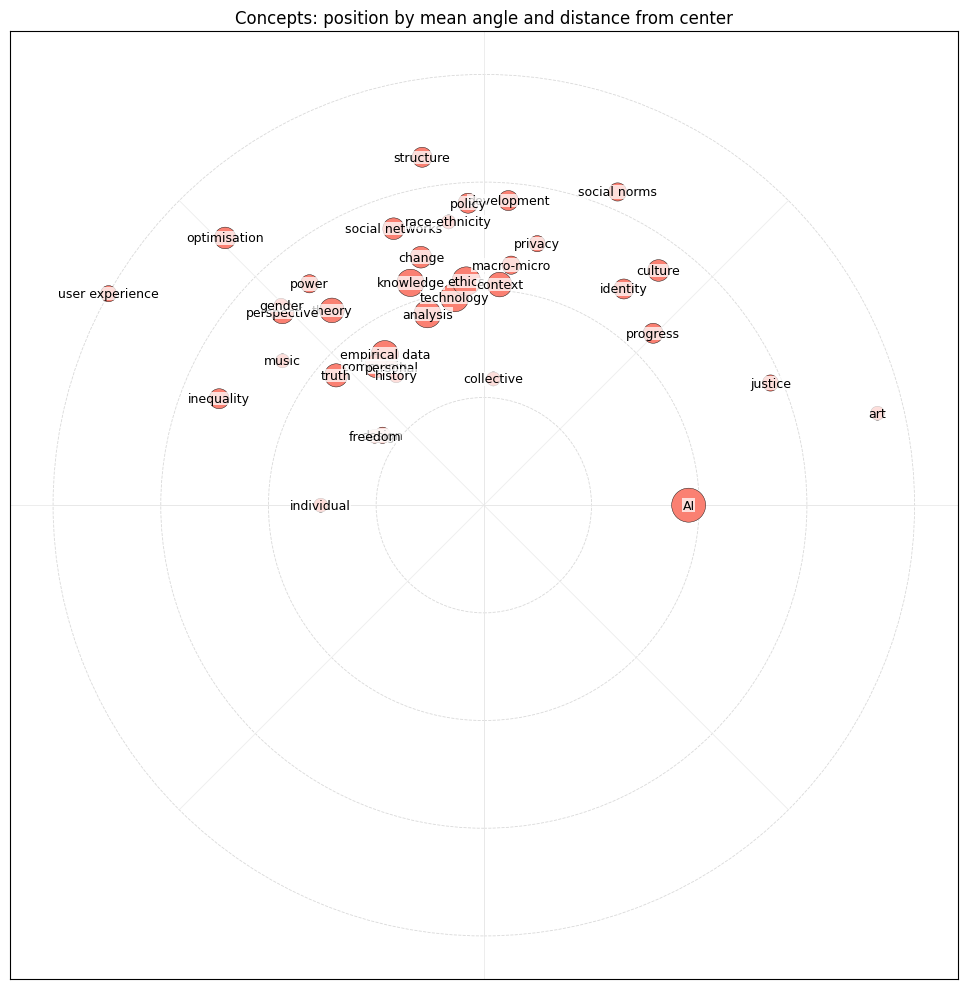

Plotted 37 concepts. Saved to concepts_circular_map.png


In [ ]:
import matplotlib.pyplot as plt

# ---------- CONFIG ----------
DF = df_concepts_all            # your final dataframe, indexed by concept name
ANGLE_COL = 'mean_angle_rad_normalized'    # radians
DIST_COL = 'distance'           # euclidean distance from center (already computed)
FREQ_COL = 'concept_count'
#RESULTANT_COL = 'resultant_length'   # optional: concentration of angles (0..1)
FIGSIZE = (10,10)
SAVE_PATH = 'concepts_circular_map.png'
GUIDE_CIRCLES = True
MAX_LABELS = None   # None = label all; or set int to label top-N by frequency
# -----------------------------

# --- Basic checks ---
if ANGLE_COL not in DF.columns and ANGLE_COL not in DF.index:
    raise KeyError(f"Angle column '{ANGLE_COL}' not found in df_concepts_all. Columns: {list(DF.columns)}")
if DIST_COL not in DF.columns:
    raise KeyError(f"Distance column '{DIST_COL}' not found in df_concepts_all. Columns: {list(DF.columns)}")

# ensure index is name
df = DF.copy()
   # 现在的逻辑：
if 'name' in df.columns:
    df = df.set_index('name')  # 直接使用 name 列作为索引

# select and drop missing rows
cols_needed = [ANGLE_COL, DIST_COL]
df_plot = df[cols_needed + [c for c in ([FREQ_COL]) if c in df.columns]].copy()
df_plot = df_plot.dropna(subset=[ANGLE_COL, DIST_COL])

# extract plotting arrays
thetas = df_plot[ANGLE_COL].astype(float).values   # radians
rs     = df_plot[DIST_COL].astype(float).values

# polar -> cartesian (center at 0,0)
xs = rs * np.cos(thetas)
ys = rs * np.sin(thetas)
df_plot['_x'] = xs
df_plot['_y'] = ys


# marker sizes based on log(concept_count)
if 'concept_count' not in df_plot.columns:
    raise KeyError("'concept_count' column not found in df_concepts_all.")

# compute log-scaled sizes (add 1 to avoid log(0))
freq = df_plot['concept_count'].astype(float)

# normalize to a visual range (e.g., 40–420)
s_min, s_max = 100, 600
if freq.max() == freq.min():
    sizes = np.full_like(freq, (s_min + s_max) / 2)
else:
    sizes = s_min + (freq - freq.min()) / (freq.max() - freq.min()) * (s_max - s_min)


# Use one color for all nodes
colors = 'salmon'      # or any Matplotlib color name, e.g. 'gray', 'crimson', '#1f77b4'
colorbar_label = None     # no colorbar needed


# choose labels (optionally top-N by freq)
if MAX_LABELS and FREQ_COL in df_plot.columns:
    label_idx = df_plot.sort_values(FREQ_COL, ascending=False).head(MAX_LABELS).index
elif MAX_LABELS:
    label_idx = df_plot.index[:MAX_LABELS]
else:
    label_idx = df_plot.index

# --- Plot ---
fig, ax = plt.subplots(figsize=FIGSIZE)
ax.set_aspect('equal')

# scatter nodes
scatter = ax.scatter(df_plot['_x'], df_plot['_y'], s=sizes, c=colors, edgecolor='k', linewidth=0.3, zorder=3)

# guide circles and radial lines
if GUIDE_CIRCLES:
    max_r = np.nanmax(rs) if len(rs)>0 else 1.0
    circles = np.linspace(0, max_r, 5)[1:]
    for r in circles:
        ax.add_artist(plt.Circle((0,0), r, color='0.85', fill=False, linestyle='--', linewidth=0.6, zorder=0))
    for deg in range(0, 360, 45):
        theta = np.deg2rad(deg)
        ax.plot([0, max_r*np.cos(theta)], [0, max_r*np.sin(theta)], color='0.93', linewidth=0.6, zorder=0)

# labels
for name in label_idx:
    row = df_plot.loc[name]
    ax.text(row['_x'], row['_y'], str(name), fontsize=9, ha='center', va='center',
            bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=0.2), zorder=4)

# optional colorbar
if colorbar_label:
    import matplotlib as mpl
    norm = mpl.colors.Normalize(vmin=vals.min(), vmax=vals.max())
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(colorbar_label)

# cosmetics (center intentionally left empty)
ax.axhline(0, color='0.9', linewidth=0.5)
ax.axvline(0, color='0.9', linewidth=0.5)
ax.set_title('Concepts: position by mean angle and distance from center')
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig(SAVE_PATH, dpi=300)
plt.show()

print(f"Plotted {len(df_plot)} concepts. Saved to {SAVE_PATH}")


Adjusted the code by changing "AI" to "ethics" for Çelikhan's individual work.